In [1]:
import torch
import torchvision
import torch.nn.functional as F
from torch import nn, optim
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import numpy as np

In [2]:
EPOCH = 10
BATCH_SIZE = 64
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")
print("Using Device:", DEVICE)

Using Device: cuda


In [3]:
trainset = datasets.FashionMNIST(
root = './.data/',
train = True,
download = True,
transform = transforms.ToTensor()
)
train_loader = torch.utils.data.DataLoader(
dataset = trainset,
batch_size = BATCH_SIZE,
shuffle = True,
num_workers = 2
)


In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3),
        )
        self.decoder = nn.Sequential(
            nn.Linear(3, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [5]:
autoencoder = Autoencoder().to(DEVICE)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.005)
criterion = nn.MSELoss()
# 변경: .type(...) 대신 .float() 사용하고 스케일링을 바로 적용
view_data = trainset.data[:5].view(-1, 28*28).float() / 255.0


In [6]:
def train(autoencoder, train_loader):
    autoencoder.train()
    for step, (x, label) in enumerate(train_loader):
        x = x.view(-1, 28*28).to(DEVICE)
        y = x.view(-1, 28*28).to(DEVICE)
        label = label.to(DEVICE)
        encoded, decoded = autoencoder(x)
        loss = criterion(decoded, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

[Epoch 1]


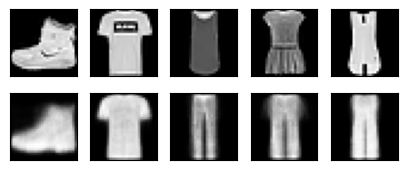

[Epoch 2]


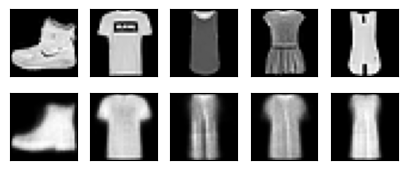

[Epoch 3]


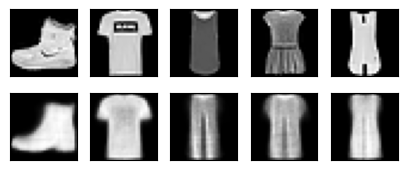

[Epoch 4]


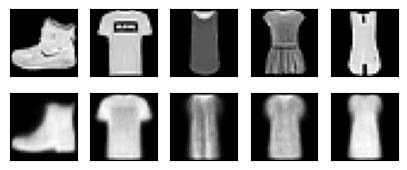

[Epoch 5]


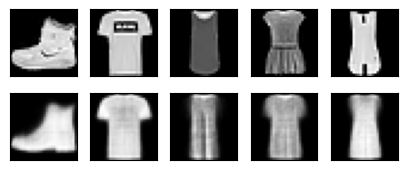

[Epoch 6]


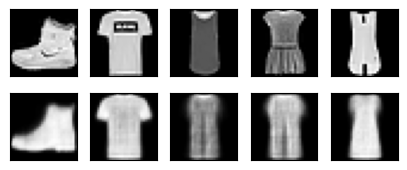

[Epoch 7]


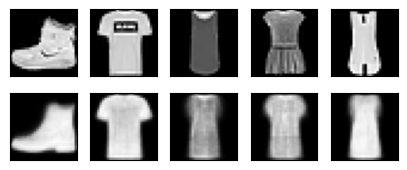

[Epoch 8]


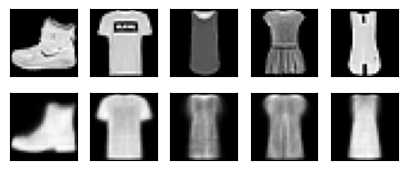

[Epoch 9]


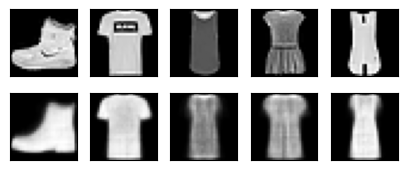

[Epoch 10]


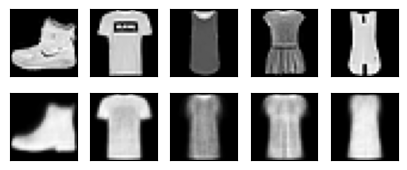

In [7]:
for epoch in range(1, EPOCH+1):
    train(autoencoder, train_loader)
    # 디코더에서 나온 이미지를 시각화 하기 (두번째 열)
    test_x = view_data.to(DEVICE)
    _, decoded_data = autoencoder(test_x)
    # 원본과 디코딩 결과 비교해보기
    f, a = plt.subplots(2, 5, figsize=(5, 2))
    print("[Epoch {}]".format(epoch))
    for i in range(5):
        # 변경: .data 제거, 안전하게 numpy 변환
        img = np.reshape(view_data.cpu().numpy()[i], (28, 28))
        a[0][i].imshow(img, cmap='gray')
        a[0][i].set_xticks(()); a[0][i].set_yticks(())
    for i in range(5):
        img = np.reshape(decoded_data.cpu().detach().numpy()[i], (28, 28))
        a[1][i].imshow(img, cmap='gray')
        a[1][i].set_xticks(()); a[1][i].set_yticks(())
    plt.show()

In [8]:
view_data = trainset.data[:200].view(-1, 28*28).float() / 255.0
test_x = view_data.to(DEVICE)
encoded_data, _ = autoencoder(test_x)
# 안전하게 CPU로 옮기고 detach
encoded_data = encoded_data.cpu().detach()
CLASSES = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

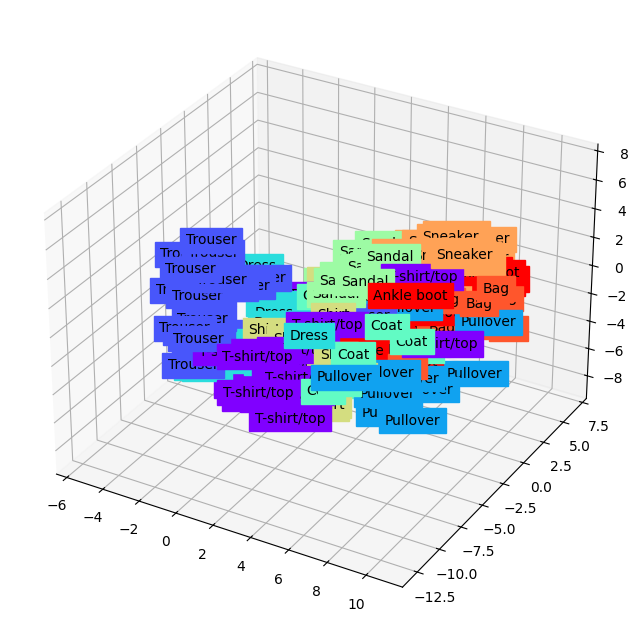

In [9]:
fig = plt.figure(figsize=(10,8))
# 변경: Axes3D 직접 호출 대신 projection 사용
ax = fig.add_subplot(111, projection='3d')

# 안전한 numpy 변환
arr = encoded_data.cpu().detach().numpy()
X = arr[:, 0]
Y = arr[:, 1]
Z = arr[:, 2]
labels = trainset.targets[:200].numpy()

# 변경: deprecated 회피 및 0..1 정규화로 색 계산
cmap = plt.get_cmap('rainbow')
n_classes = len(CLASSES)
for x, y, z, s in zip(X, Y, Z, labels):
    name = CLASSES[int(s)]
    color = cmap(int(s) / (n_classes - 1))
    ax.text(x, y, z, name, backgroundcolor=color)

ax.set_xlim(X.min(), X.max())
ax.set_ylim(Y.min(), Y.max())
ax.set_zlim(Z.min(), Z.max())
plt.show()

-------------------------------------------

In [10]:
def add_noise(img):
    noise = torch.randn(img.size()) * 0.2
    noisy_img = img + noise
    return noisy_img

In [11]:
def train(autoencoder, train_loader):
    autoencoder.train()
    avg_loss = 0
    for step, (x, label) in enumerate(train_loader):
        noisy_x = add_noise(x)  # 입력에 노이즈 더하기
        noisy_x = noisy_x.view(-1, 28*28).to(DEVICE)
        y = x.view(-1, 28*28).to(DEVICE)
        label = label.to(DEVICE)
        encoded, decoded = autoencoder(noisy_x)
        loss = criterion(decoded, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.item()
    return avg_loss / len(train_loader)

In [12]:
testset = datasets.FashionMNIST(
    root      = './.data/', 
    train     = False,
    download  = True,
    transform = transforms.ToTensor(),
)
# 변경: 배치 차원 명확히 추가, .float() 사용
sample_data = testset.data[0].view(1, 28*28).float() / 255.0
original_x = sample_data[0]                  # 1D (784,)
noisy_x = add_noise(original_x).unsqueeze(0).to(DEVICE)  # (1,784)
_, recovered_x = autoencoder(noisy_x)
# recovered_x -> CPU, 1D tensor
recovered_x = recovered_x.squeeze(0).cpu().detach()

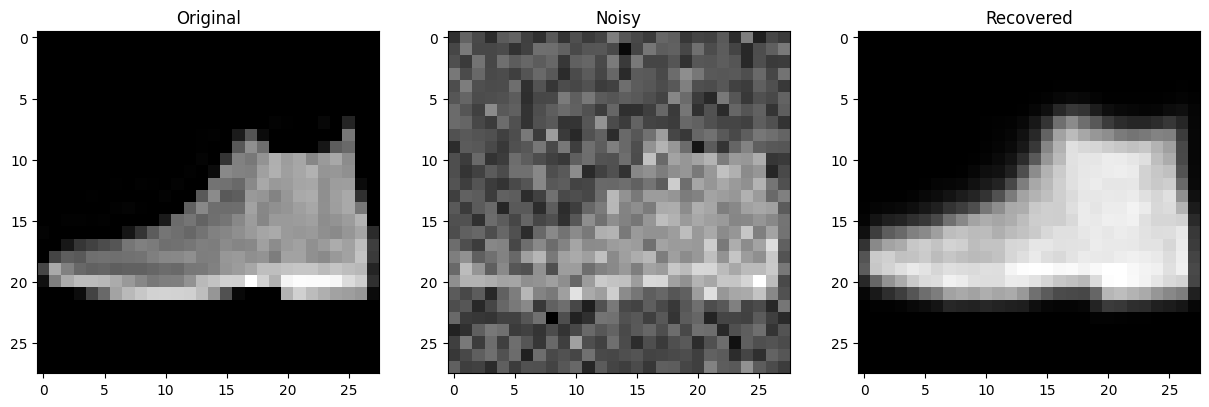

In [13]:
f, a = plt.subplots(1, 3, figsize=(15, 15))
original_img = original_x.cpu().numpy().reshape((28, 28))
noisy_img = noisy_x.cpu().detach().squeeze(0).numpy().reshape((28, 28))
recovered_img = recovered_x.numpy().reshape((28, 28))
a[0].set_title('Original')
a[0].imshow(original_img, cmap='gray')
a[1].set_title('Noisy')
a[1].imshow(noisy_img, cmap='gray')
a[2].set_title('Recovered')
a[2].imshow(recovered_img, cmap='gray')
plt.show()